In [24]:
import polars as pl

# Read Dataset

> Precondition: data passed through phase 1

In [15]:
# continue working with base lazy frame from phase 1
base = pl.scan_parquet("new_base.parquet")

base.head(3).collect()

article_id,title,url,published_date,year,quarter_year,content,news_site,topics
str,str,str,datetime[μs],i32,str,str,str,list[struct[3]]
"""'Doesn't really make a differe…","""'Doesn't really make a differe…","""https://www.channelnewsasia.co…",2022-08-08 23:31:00,2022,"""2022Q3""","""Affected residents were sent a…","""cna""","[{""BTO and New Flat Supply"",0.0,""The sentiment is neutral as it's primarily a policy announcement without clear positive or negative reactions from residents.""}, {""Diminishing Lease, SERS and VERS"",-0.6,""Residents express concerns and dissatisfaction with the SERS process, including financial implications and forced relocation.""}, {""Housing Affordability and Financial Stress"",-0.7,""Residents are worried about the financial implications of moving to new flats, especially for retirees who may struggle with top-ups.""}]"
"""'Fair wear and tear' disputes …","""'Fair wear and tear' disputes …","""https://www.channelnewsasia.co…",2021-07-01 14:08:12,2021,"""2021Q3""","""After seven years in Singapore…","""cna""","[{""Housing Affordability and Financial Stress"",-0.2,""The dispute over a significant portion of the rental deposit indicates potential financial stress for tenants.""}, {""Private Residential Rental Market"",-0.3,""The article highlights negative experiences and disputes between tenants and landlords, indicating some tension in the rental market.""}]"
"""'Feels like a fan': Tengah hom…","""'Feels like a fan': Tengah hom…","""https://www.channelnewsasia.co…",2023-10-13 06:00:00,2023,"""2023Q4""","""SP Group has assured Tengah re…","""cna""","[{""Public Housing Quality, Maintenance and Estate Living"",-0.6,""Residents report multiple problems with the cooling system, expressing dissatisfaction with its performance and reliability.""}, {""Urban Planning and New Town Development"",0.2,""While there are issues with the cooling system, the overall concept of a smart and sustainable town is presented positively.""}]"


# Phase 2: Data flattening

In [26]:
def assert_data_correctly_flattened(
    base: pl.LazyFrame,
    flattened: pl.LazyFrame,
) -> None:
    expected_rows = (
        base.select(
            pl.col("topics").list.len().sum()
        )
        .collect()
        .item()
    )

    actual_rows = (
        flattened.select(pl.len())
        .collect()
        .item()
    )

    assert expected_rows == actual_rows, (
        f"Flattening produced {actual_rows} rows, "
        f"expected {expected_rows} article-topic pairs."
    )

In [27]:
# flatten topics such that each topic appears in one row
# one line wonder
flattened = base.explode("topics").unnest("topics")
assert_data_correctly_flattened(base, flattened)

# create article_topic_key which uniquely identifies each article + topic
flattened = flattened.with_columns(
    article_topic_key=pl.concat_str(
        [pl.col('article_id'), pl.col("topic")],
        separator=" | "
    )
)

# move article_topic_key from last column to the column at index 1
cols = flattened.collect_schema().names()
reordered_cols = [cols[0]] + [cols[-1]] + cols[1:-1]
flattened = flattened.select(reordered_cols)

# drop content column (not needed for sql queries)
flattened = flattened.drop("content")

flattened.collect()

In [21]:
flattened.sink_parquet("new_flat.parquet")

# Appendix: Query explainer

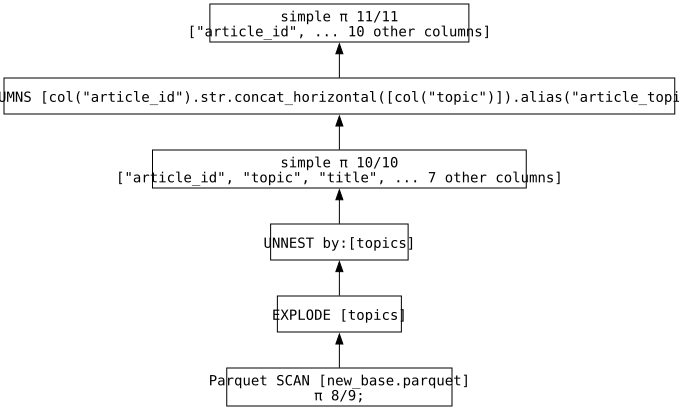

In [22]:
flattened.show_graph()